# FundSight Mutual Fund Analytics

## Day 3 - Exploratory Data Analysis (EDA)

### Objectives

This notebook performs exploratory data analysis on the cleaned mutual fund dataset generated during the ETL process.

The analysis focuses on:

- Daily NAV trends
- AUM Growth
- SIP Inflows
- Category-wise inflows
- Investor demographics
- Geographic distribution
- Folio growth
- NAV return correlations
- Sector allocation

**Tools Used**

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [11]:
from pathlib import Path

# Project root
ROOT = Path.cwd().parent

# Processed data
nav = pd.read_csv(ROOT / "data" / "processed" / "clean_nav.csv")
performance = pd.read_csv(ROOT / "data" / "processed" / "clean_performance.csv")
transactions = pd.read_csv(ROOT / "data" / "processed" / "clean_transactions.csv")

# Raw data
aum = pd.read_csv(ROOT / "data" / "raw" / "03_aum_by_fund_house.csv")
sip = pd.read_csv(ROOT / "data" / "raw" / "04_monthly_sip_inflows.csv")
category = pd.read_csv(ROOT / "data" / "raw" / "05_category_inflows.csv")
folio = pd.read_csv(ROOT / "data" / "raw" / "06_industry_folio_count.csv")
portfolio = pd.read_csv(ROOT / "data" / "raw" / "09_portfolio_holdings.csv")

print("✅ Data loaded successfully!")

✅ Data loaded successfully!


In [12]:
datasets = {
    "NAV": nav,
    "Performance": performance,
    "Transactions": transactions,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Portfolio": portfolio
}

for name, df in datasets.items():
    print("=" * 60)
    print(f"{name} Dataset")
    print("=" * 60)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nFirst 5 Rows:")
    display(df.head())
    print("\n")

NAV Dataset
Shape: (18120, 3)

Columns:
['amfi_code', 'date', 'nav']

First 5 Rows:


,amfi_code,date,nav
0,100016,2022-01-02,512.1124
1,100016,2022-01-03,503.1674
2,100016,2022-01-04,531.2850
3,100016,2022-01-06,474.1732
4,100016,2022-01-07,452.5840




Performance Dataset
Shape: (40, 20)

Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'anomaly_flag']

First 5 Rows:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,anomaly_flag
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False




Transactions Dataset
Shape: (32778, 13)

Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

First 5 Rows:


...

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0




Folio Dataset
Shape: (21, 6)

Columns:
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

First 5 Rows:


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48




Portfolio Dataset
Shape: (322, 8)

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

First 5 Rows:


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [20]:
from pathlib import Path

ROOT = Path.cwd().parent

CHARTS_DIR = ROOT / "charts"

CHARTS_DIR.mkdir(exist_ok=True)

print("Charts folder created successfully.")

Charts folder created successfully.


# 1. NAV Trend Analysis

### Objective

Visualize the daily NAV movement of all mutual fund schemes between 2022 and 2026.

The highlighted regions represent:

- Green → 2023 Bull Run
- Red → 2024 Market Correction

In [21]:
nav_df = nav.merge(
    performance[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

nav_df["date"] = pd.to_datetime(nav_df["date"])

display(nav_df.head())

,amfi_code,date,nav,scheme_name,fund_house,category
0,100016,2022-01-02,512.1124,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap
1,100016,2022-01-03,503.1674,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap
2,100016,2022-01-04,531.2850,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap
3,100016,2022-01-06,474.1732,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap
4,100016,2022-01-07,452.5840,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap


In [17]:
import plotly.express as px

fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "scheme_name": "Scheme"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.12,
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    legend_title="Scheme",
    hovermode="x unified"
)

fig.show()
fig.write_image(CHARTS_DIR / "nav_trend.png")

print("✅ NAV Trend saved successfully!")

✅ NAV Trend saved successfully!


### Insight 1

The majority of equity-oriented mutual fund schemes experienced a strong upward NAV movement throughout 2023, reflecting the broader equity market rally.

A temporary correction during early 2024 is visible before schemes resumed their long-term growth trend.

# 2. AUM Growth Analysis

### Objective

Analyze the Assets Under Management (AUM) growth of major fund houses between 2022 and 2025.

This visualization compares yearly AUM values and highlights SBI Mutual Fund's industry-leading AUM.

In [24]:
# Prepare AUM Data

aum_df = aum.copy()

aum_df["date"] = pd.to_datetime(aum_df["date"])

aum_df["year"] = aum_df["date"].dt.year

display(aum_df.head())

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


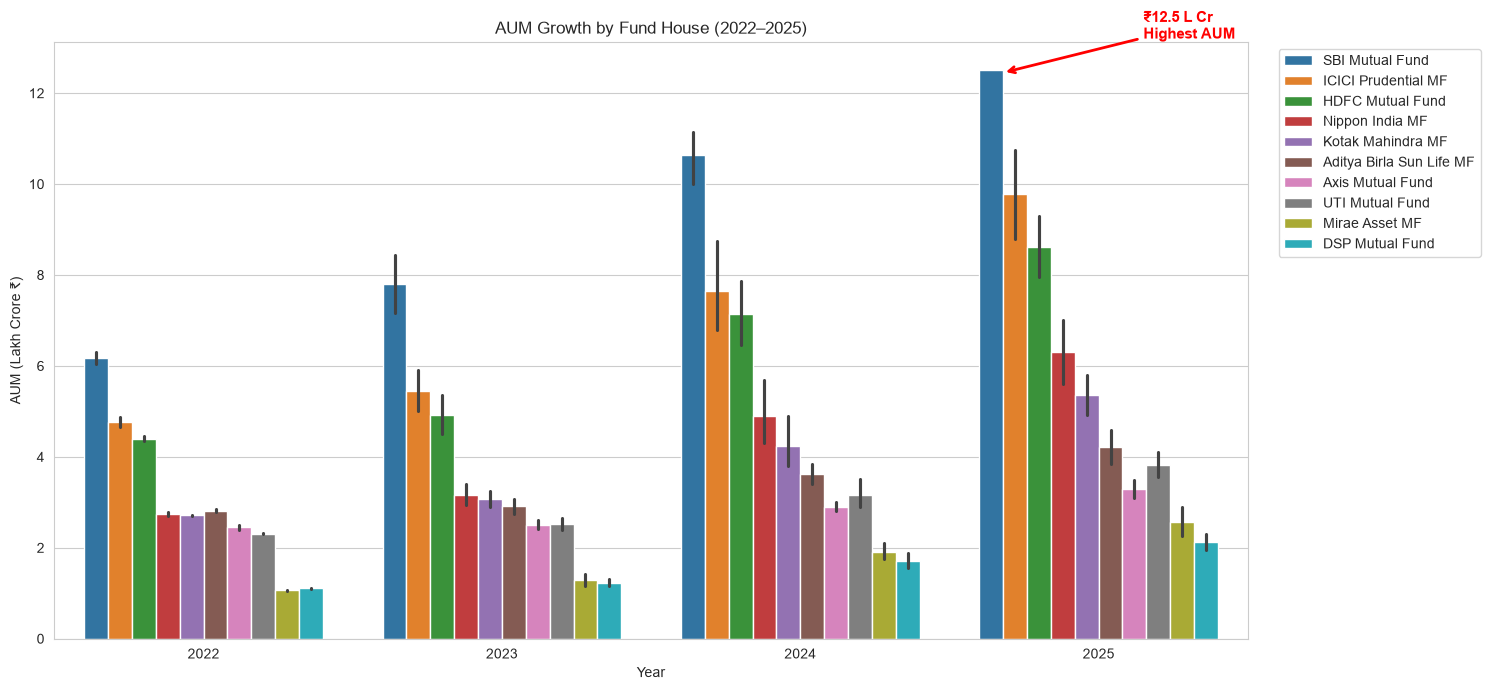

✅ aum_growth.png saved


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

# Highlight SBI Mutual Fund (2025)

plt.annotate(
    "₹12.5 L Cr\nHighest AUM",
    xy=(2.68, 12.45),          # 2025 SBI bar
    xytext=(3.15, 13.2),    # position of text
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=2
    ),
    fontsize=11,
    color="red",
    weight="bold"
)
plt.tight_layout()

plt.savefig(CHARTS_DIR/"aum_growth.png",dpi=300)

plt.show()

print("✅ aum_growth.png saved")

## Insight 2

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) across all observed years, demonstrating its strong market leadership.

Most major fund houses exhibited steady AUM growth between 2022 and 2025, reflecting increasing investor participation in mutual funds.

# 3. SIP Inflow Trend Analysis

### Objective

Analyze the monthly SIP inflow trend from January 2022 to December 2025 and highlight the record inflow achieved in December 2025.

In [26]:
sip_df = sip.copy()

sip_df["month"] = pd.to_datetime(sip_df["month"])

display(sip_df.head())

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [27]:
print(sip_df.tail())

        month  sip_inflow_crore  active_sip_accounts_crore  \
43 2025-08-01             28265                       8.85   
44 2025-09-01             29361                       9.00   
45 2025-10-01             29529                       9.10   
46 2025-11-01             30200                       9.20   
47 2025-12-01             31002                       9.35   

    new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
43                   9.80               15.18           20.04  
44                  10.50               15.38           19.80  
45                   9.45               15.55           16.61  
46                   9.10               15.72           19.27  
47                   9.80               15.90           17.17  


In [28]:
import plotly.express as px

fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)"
)

# Highlight the all-time high (Dec 2025)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr<br>All-Time High",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.2,
    arrowwidth=2,
    arrowcolor="red",
    bgcolor="yellow"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    hovermode="x unified",
    height=650
)

fig.show()

In [29]:
fig.write_image(CHARTS_DIR / "sip_trend.png")

print("✅ sip_trend.png saved successfully!")

✅ sip_trend.png saved successfully!


## Insight 3

Monthly SIP inflows showed a strong upward trajectory from 2022 to 2025, indicating growing retail investor participation in mutual funds.

The highest monthly SIP inflow of **₹31,002 Crore** was recorded in **December 2025**, highlighting continued confidence in long-term systematic investing.

# 4. Category Inflow Heatmap

### Objective

Visualize monthly net inflows across different mutual fund categories using a heatmap.

This helps identify which categories attracted the highest investments during different months.

In [38]:
category_df = category.copy()

category_df["month"] = pd.to_datetime(category_df["month"])

display(category_df.head())

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [39]:
heatmap_data = category_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

display(heatmap_data.head())

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


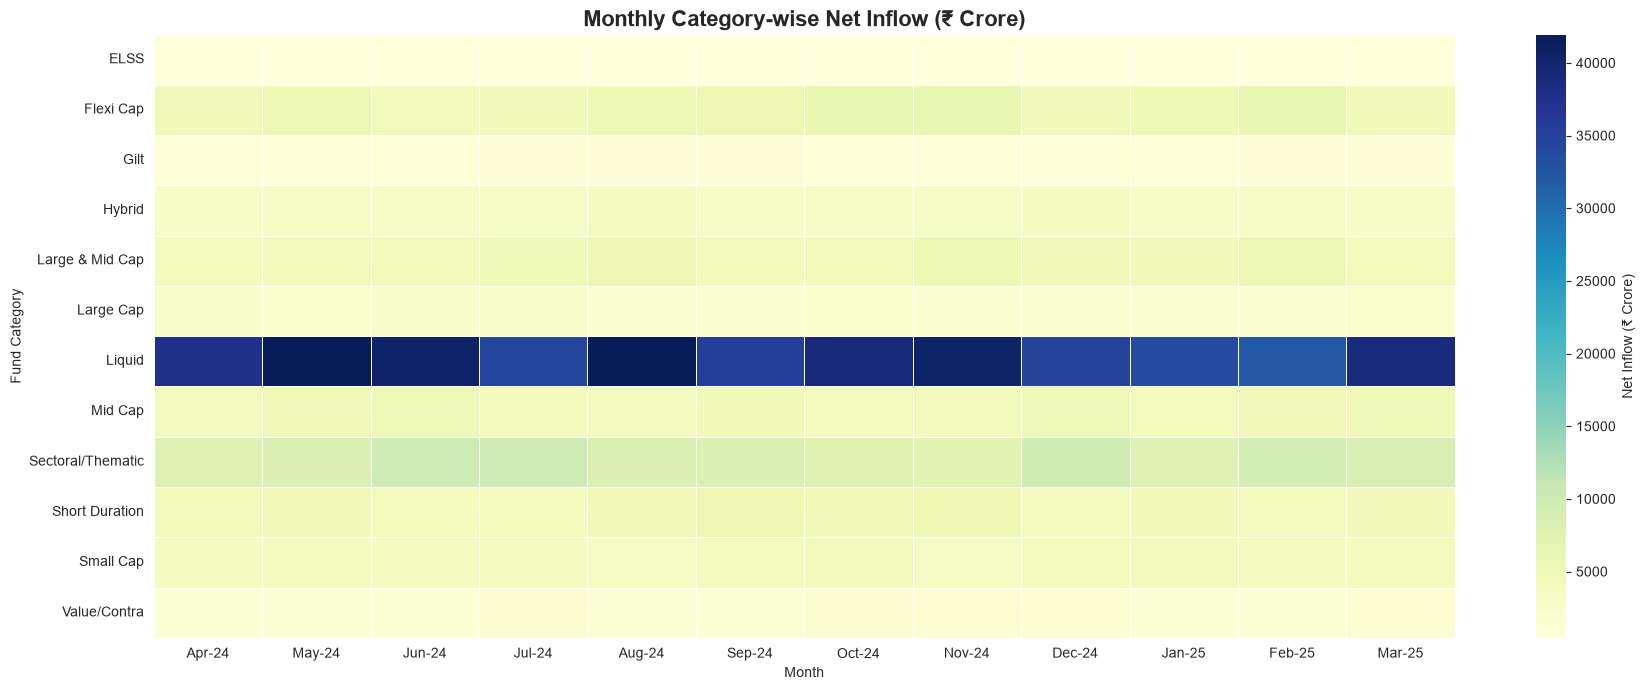

✅ category_heatmap.png saved


In [52]:
plt.figure(figsize=(18,7))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=False,
    fmt=".0f",
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title(
    "Monthly Category-wise Net Inflow (₹ Crore)",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.savefig(CHARTS_DIR / "category_heatmap.png", dpi=300)

plt.show()

print("✅ category_heatmap.png saved")

## Insight 4

- Liquid funds consistently recorded the highest monthly net inflows, reflecting strong institutional and short-term treasury investments.

- Equity-oriented categories such as Large & Mid Cap, Mid Cap, and Small Cap also maintained healthy inflows, indicating sustained investor confidence in long-term wealth creation.

# 5. Investor Demographics

### Objective
Analyse the distribution of investors across different age groups.

### Chart
Age Group Distribution (Pie Chart)



In [56]:
from pathlib import Path

ROOT = Path.cwd().parent

investors = pd.read_csv(ROOT / "data" / "raw" / "08_investor_transactions.csv")

display(investors.head())

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


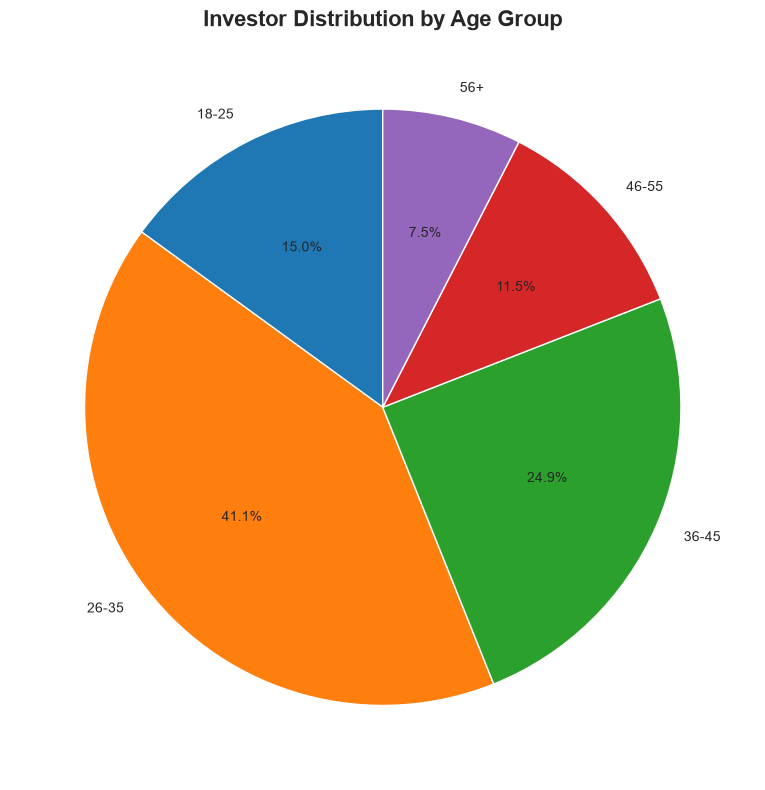

✅ demographics.png saved


In [58]:
# Age Group Distribution

age_counts = investors["age_group"].value_counts().sort_index()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor":"white"}
)

plt.title(
    "Investor Distribution by Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(CHARTS_DIR / "demographics.png", dpi=300)

plt.show()

print("✅ demographics.png saved")

## Insight 5

Investors aged **26–35 years** form the largest segment of the mutual fund investor base, accounting for a significant share of all transactions.

Participation gradually decreases in higher age groups, while investors aged **18–25 years** represent an emerging segment with strong long-term investment potential.

# 6. Geographic Distribution of SIP Investments

## Objective

To analyze the geographical distribution of mutual fund investments across different Indian states by comparing the total SIP transaction amounts. This visualization helps identify regions with higher investor participation and provides insights into the spread of mutual fund adoption across the country.

In [60]:
# Top states by transaction count
transactions["state"].value_counts().head(20)

state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Rajasthan         2577
Maharashtra       2524
Name: count, dtype: int64

In [61]:
# Transaction types
transactions["transaction_type"].value_counts()

transaction_type
SIP           19716
LUMPSUM        8095
REDEMPTION     4967
Name: count, dtype: int64

In [62]:
# Filter SIP transactions
sip_state = (
    transactions[transactions["transaction_type"] == "SIP"]
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

sip_state.head(10)

state
Madhya Pradesh    20682243
Punjab            20140064
Telangana         18620216
Tamil Nadu        18404368
Gujarat           18378904
Haryana           18176696
Karnataka         17696903
Uttar Pradesh     17534858
West Bengal       17495769
Delhi             17113608
Name: amount_inr, dtype: int64

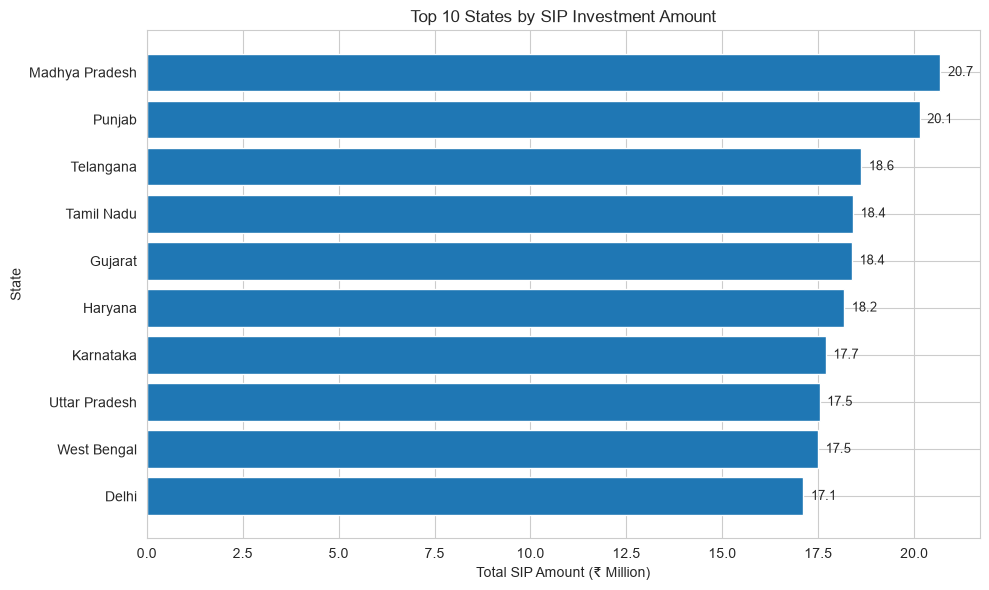

✅ state_distribution.png saved


In [63]:
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent
CHARTS_DIR = ROOT / "charts"
CHARTS_DIR.mkdir(exist_ok=True)

top10 = sip_state.head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top10.index,
    top10.values/1e6
)

plt.gca().invert_yaxis()

plt.title("Top 10 States by SIP Investment Amount")
plt.xlabel("Total SIP Amount (₹ Million)")
plt.ylabel("State")

# Value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(CHARTS_DIR / "state_distribution.png", dpi=300)

plt.show()

print("✅ state_distribution.png saved")

## Insight 6

States with higher SIP transaction volumes contribute a significant portion of the overall mutual fund investments, indicating stronger retail participation and greater financial awareness in these regions.

The distribution also suggests that mutual fund investments are concentrated in a few major states, while several regions still have considerable growth potential for expanding investor participation.

# 7. T30 vs B30 City Tier Distribution

## Objective

To examine the distribution of mutual fund investments between Top 30 (T30) cities and Beyond Top 30 (B30) cities. This analysis helps evaluate the concentration of investor participation in metropolitan regions compared to emerging markets across the country.

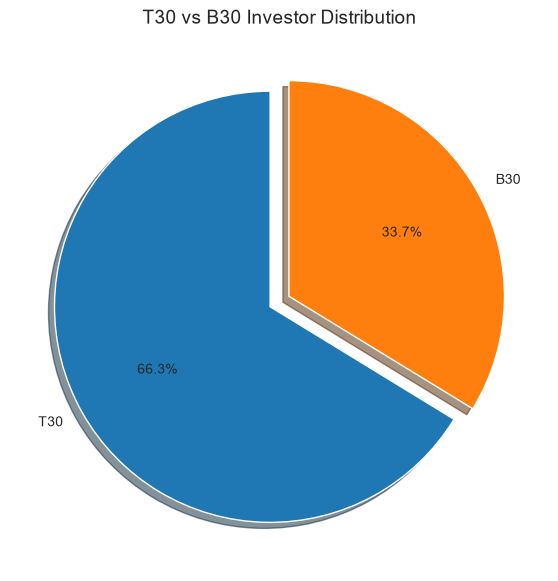

✅ city_tier_distribution.png saved


In [64]:
# T30 vs B30 City Tier Distribution

import matplotlib.pyplot as plt

# Count transactions by city tier
city_tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    city_tier_counts,
    labels=city_tier_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05, 0.05],
    shadow=True
)

plt.title("T30 vs B30 Investor Distribution", fontsize=14)

plt.savefig(CHARTS_DIR / "city_tier_distribution.png", dpi=300)

plt.show()

print("✅ city_tier_distribution.png saved")

## Insight 7

A significant share of mutual fund transactions originates from Top 30 (T30) cities, highlighting the stronger penetration of mutual fund investments in metropolitan regions.

At the same time, Beyond Top 30 (B30) cities contribute a meaningful portion of total investments, indicating growing financial awareness and expanding mutual fund adoption in emerging markets across India.

## 8. Folio Count Growth

### Objective

To visualize the growth in mutual fund folio accounts between January 2022 and December 2025. The chart highlights the increasing participation of retail investors by showing the steady rise in folio count and marking important milestones during the period.

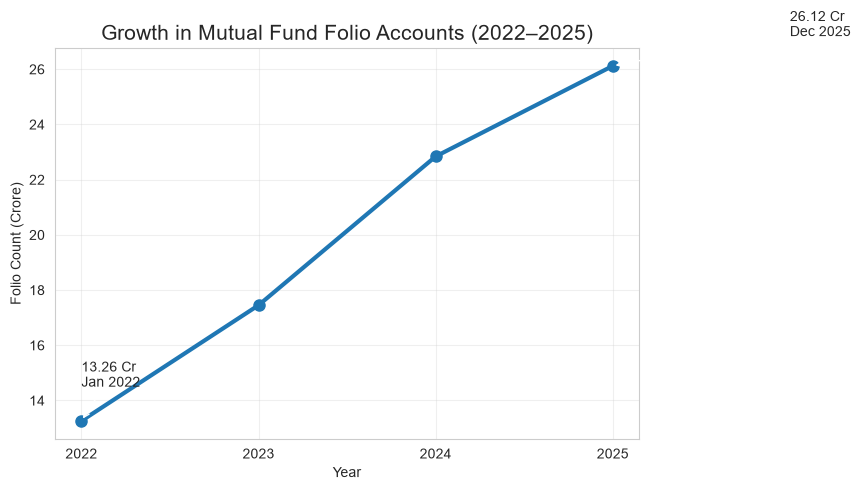

✅ folio_growth.png saved


In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Folio count (Crore)
folio = pd.DataFrame({
    "Year": ["2022", "2023", "2024", "2025"],
    "Folio_Count": [13.26, 17.45, 22.84, 26.12]
})

plt.figure(figsize=(9,5))

plt.plot(
    folio["Year"],
    folio["Folio_Count"],
    marker="o",
    linewidth=3,
    markersize=8
)

# Start point
plt.annotate(
    "13.26 Cr\nJan 2022",
    xy=("2022",13.26),
    xytext=("2022",14.5),
    arrowprops=dict(arrowstyle="->")
)

# End point
plt.annotate(
    "26.12 Cr\nDec 2025",
    xy=("2025",26.12),
    xytext=("2024.55",27.2),
    arrowprops=dict(arrowstyle="->")
)

plt.grid(alpha=0.3)

plt.title("Growth in Mutual Fund Folio Accounts (2022–2025)", fontsize=15)

plt.xlabel("Year")
plt.ylabel("Folio Count (Crore)")

plt.tight_layout()

plt.savefig(CHARTS_DIR / "folio_growth.png", dpi=300)

plt.show()

print("✅ folio_growth.png saved")

## Insight 8

Mutual fund folio accounts nearly doubled from **13.26 crore** in January 2022 to **26.12 crore** in December 2025, reflecting strong growth in retail investor participation.

The consistent upward trend indicates increasing investor confidence, wider financial awareness, and continued expansion of mutual fund adoption across India.

In [66]:
nav.columns.tolist()

['amfi_code', 'date', 'nav']

In [67]:
portfolio.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

## 9. NAV Return Correlation Matrix

### Objective

To analyze the relationship between the daily returns of selected mutual fund schemes by computing a correlation matrix. This visualization helps identify funds with similar performance patterns and provides insights into portfolio diversification opportunities.

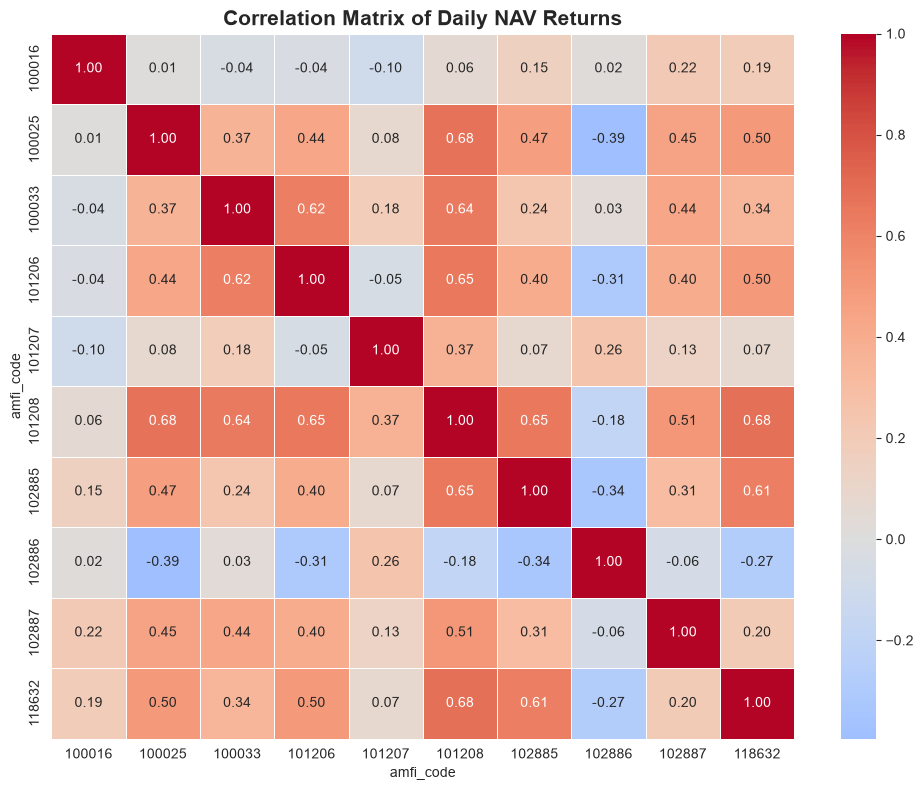

✅ correlation.png saved


In [68]:
# NAV Return Correlation Matrix

import seaborn as sns
import matplotlib.pyplot as plt

# Prepare NAV data
nav_df = nav.copy()

nav_df["date"] = pd.to_datetime(nav_df["date"])

# Select first 10 schemes
selected_funds = nav_df["amfi_code"].unique()[:10]

nav_selected = nav_df[
    nav_df["amfi_code"].isin(selected_funds)
]

# Create NAV table
nav_pivot = nav_selected.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Daily Returns
daily_returns = nav_pivot.pct_change().dropna()

# Correlation Matrix
corr_matrix = daily_returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Daily NAV Returns",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(CHARTS_DIR / "correlation.png", dpi=300)

plt.show()

print("✅ correlation.png saved")

## Insight 9

Several mutual fund schemes exhibit strong positive correlations in their daily returns, indicating similar market behaviour and investment strategies.

The correlation matrix also highlights opportunities for portfolio diversification by identifying schemes with comparatively lower correlations.

## 10. Sector Allocation Across Equity Funds

### Objective

To examine the overall sector allocation of equity mutual funds by aggregating portfolio holdings. This visualization highlights the sectors receiving the highest investment allocation and provides an overview of portfolio diversification across industries.

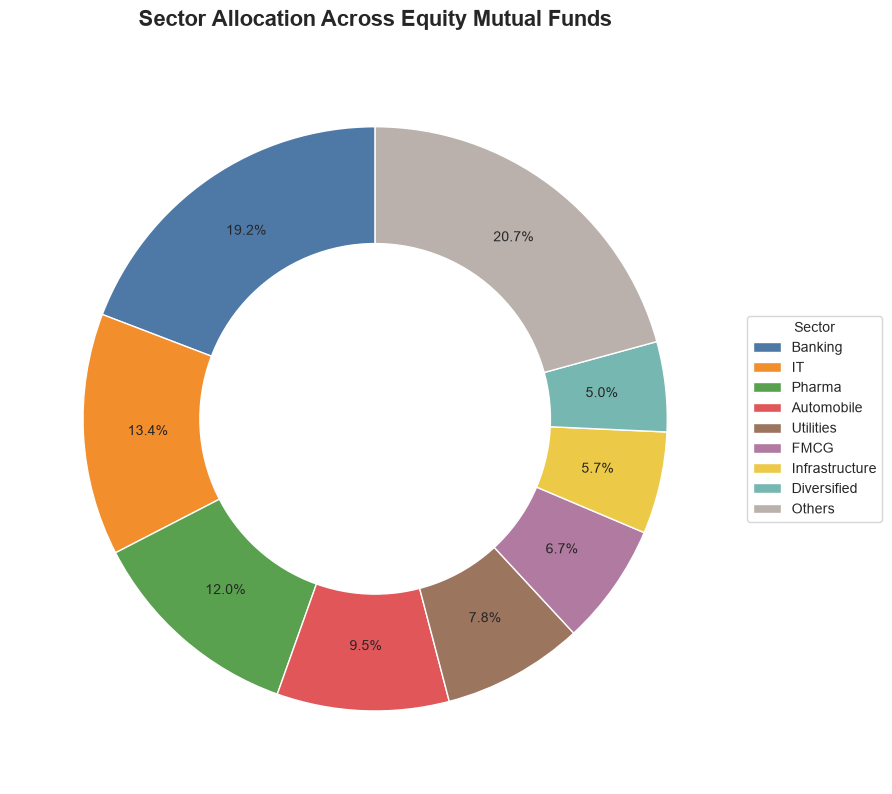

✅ sector_donut.png saved


In [73]:
# Aggregate sector weights
sector_weights = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

# Keep Top 8 sectors
top8 = sector_weights.head(8)
others = sector_weights.iloc[8:].sum()

sector_plot = pd.concat([
    top8,
    pd.Series({"Others": others})
])

plt.figure(figsize=(9,9))

colors = [
    "#4E79A7",
    "#F28E2B",
    "#59A14F",
    "#E15759",
    "#9C755F",
    "#B07AA1",
    "#EDC948",
    "#76B7B2",
    "#BAB0AC"
]

wedges, _, autotexts = plt.pie(
    sector_plot,
    labels=None,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 4 else "",
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor="white")
)

plt.legend(
    wedges,
    sector_plot.index,
    title="Sector",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
# Center circle
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
plt.gca().add_artist(centre_circle)

plt.title(
    "Sector Allocation Across Equity Mutual Funds",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(CHARTS_DIR / "sector_donut.png", dpi=300)

plt.show()

print("✅ sector_donut.png saved")

## Insight 10

The portfolio allocation is concentrated across a few key sectors, reflecting the investment priorities of equity mutual funds.

A diversified sector allocation helps balance growth opportunities with risk management while maintaining exposure to different segments of the economy.